# 5G Throughput Prediction

# 1. Setup: Dataset 다운로드

In [ ]:
!git clone https://github.com/uccmisl/5Gdataset.git
!unzip -q 5Gdataset/5G-production-dataset.zip -d 5Gdataset/
!ls 5Gdataset
!ls 5Gdataset/5G-production-dataset/

Cloning into '5Gdataset'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 32 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 2.04 MiB | 29.85 MiB/s, done.
Resolving deltas: 100% (12/12), done.
5G-framework-README.md	5G-production-dataset.zip  __MACOSX
5G-production-dataset	LICENSE			   README.md
Amazon_Prime  Download	Netflix


In [ ]:
import pandas as pd
import glob
csv_files=glob.glob('5Gdataset/**/*.csv', recursive=True)
print(f"총 CSV 파일 수: {len(csv_files)}")
print("처음 3개:", csv_files[:3])

df=pd.read_csv(csv_files[0])
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
df.head()

총 CSV 파일 수: 83
처음 3개: ['5Gdataset/5G-production-dataset/Netflix/Static/Season3-StrangerThings/B_2019.12.03_08.02.05.csv', '5Gdataset/5G-production-dataset/Netflix/Static/Season3-StrangerThings/B_2019.12.06_09.55.13.csv', '5Gdataset/5G-production-dataset/Netflix/Static/Season3-StrangerThings/B_2019.11.28_09.21.45.csv']

Shape: (7190, 26)

Columns: ['Timestamp', 'Longitude', 'Latitude', 'Speed', 'Operatorname', 'CellID', 'NetworkMode', 'RSRP', 'RSRQ', 'SNR', 'CQI', 'RSSI', 'DL_bitrate', 'UL_bitrate', 'State', 'PINGAVG', 'PINGMIN', 'PINGMAX', 'PINGSTDEV', 'PINGLOSS', 'CELLHEX', 'NODEHEX', 'LACHEX', 'RAWCELLID', 'NRxRSRP', 'NRxRSRQ']

Head:


,Timestamp,Longitude,Latitude,Speed,Operatorname,CellID,NetworkMode,RSRP,RSRQ,SNR,...,PINGMIN,PINGMAX,PINGSTDEV,PINGLOSS,CELLHEX,NODEHEX,LACHEX,RAWCELLID,NRxRSRP,NRxRSRQ
0,2019.12.03_08.02.06,-8.482086,51.900862,0,B,13,5G,-79,-9,4.0,...,-,-,-,-,D,A992,9CBA,11112973,-81.0,-12.0
1,2019.12.03_08.02.06,-8.482086,51.900862,0,B,13,5G,-79,-9,4.0,...,-,-,-,-,D,A992,9CBA,11112973,-81.0,-12.0
2,2019.12.03_08.02.08,-8.482086,51.900862,0,B,13,5G,-80,-10,0.0,...,-,-,-,-,D,A992,9CBA,11112973,-81.0,-10.0
3,2019.12.03_08.02.09,-8.482086,51.900862,0,B,13,5G,-80,-10,0.0,...,-,-,-,-,D,A992,9CBA,11112973,-81.0,-10.0
4,2019.12.03_08.02.10,-8.482086,51.900862,0,B,13,5G,-79,-9,0.0,...,-,-,-,-,D,A992,9CBA,11112973,-81.0,-9.0


# 2. EDA: 데이터 탐색

In [ ]:
# 2.1 첫 trace 컬럼·결측치 확인
print("Describe:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

print("\nDtypes:")
print(df.dtypes)

Describe:
          Longitude      Latitude   Speed        CellID         RSRP  \
count  7.190000e+03  7.190000e+03  7190.0   7190.000000  7190.000000   
mean  -8.482086e+00  5.190086e+01     0.0    335.472045   -79.513074   
std    1.664562e-12  5.436030e-12     0.0   1863.595382     4.637301   
min   -8.482086e+00  5.190086e+01     0.0      2.000000  -200.000000   
25%   -8.482086e+00  5.190086e+01     0.0     13.000000   -81.000000   
50%   -8.482086e+00  5.190086e+01     0.0     13.000000   -80.000000   
75%   -8.482086e+00  5.190086e+01     0.0     13.000000   -79.000000   
max   -8.482086e+00  5.190086e+01     0.0  37389.000000   -53.000000   

          DL_bitrate   UL_bitrate     RAWCELLID  
count    7190.000000  7190.000000  7.190000e+03  
mean      758.986648     7.612100  1.136966e+07  
std      5035.120182    50.691402  1.465622e+06  
min         0.000000     0.000000  1.111296e+07  
25%         0.000000     0.000000  1.111297e+07  
50%         0.000000     0.000000  1.1112

In [ ]:
# 2.2 시나리오별 trace 분포
import pandas as pd
import glob
from collections import Counter

csv_files = sorted(glob.glob('5Gdataset/**/*.csv', recursive=True))
print(f"Total CSV files: {len(csv_files)}\n")

def parse_scenario(filepath):
    parts = filepath.split('/')
    return parts[2], parts[3]

scenarios = [parse_scenario(f) for f in csv_files]
print("App별:")
for app, c in Counter(s[0] for s in scenarios).most_common():
    print(f"  {app}: {c}")

print("\nMobility별:")
for mob, c in Counter(s[1] for s in scenarios).most_common():
    print(f"  {mob}: {c}")

print("\nApp × Mobility:")
for combo, c in sorted(Counter(scenarios).items()):
    print(f"  {combo[0]} / {combo[1]}: {c}")

Total CSV files: 83

App별:
  Netflix: 33
  Amazon_Prime: 29
  Download: 21

Mobility별:
  Driving: 60
  Static: 23

App × Mobility:
  Amazon_Prime / Driving: 21
  Amazon_Prime / Static: 8
  Download / Driving: 16
  Download / Static: 5
  Netflix / Driving: 23
  Netflix / Static: 10


In [ ]:
# 2.3 Driving trace 변동성 확인
driving_files = [f for f in csv_files if '/Driving/' in f]
print(f"Driving traces: {len(driving_files)}\n")

df_drive = pd.read_csv(driving_files[0])
print(f"File: {driving_files[0]}")
print(f"Shape: {df_drive.shape}\n")

print("NetworkMode value counts:")
print(df_drive['NetworkMode'].value_counts())

print(f"\nCellID nunique (handover 횟수 proxy): {df_drive['CellID'].nunique()}")
print(f"Speed range: {df_drive['Speed'].min()} ~ {df_drive['Speed'].max()}")

print("\nDL_bitrate describe:")
print(df_drive['DL_bitrate'].describe())

# RF KPI에 "-"가 있는지 확인
print("\nRF KPI에서 '-' 등장 횟수:")
for col in ['RSRP', 'RSRQ', 'SNR', 'CQI', 'RSSI', 'NRxRSRP', 'NRxRSRQ']:
    n_dash = (df_drive[col].astype(str) == '-').sum()
    n_total = len(df_drive)
    if n_dash > 0:
        print(f"  {col}: {n_dash}/{n_total} ({n_dash/n_total*100:.1f}%)")
print("(아무것도 안 찍히면 이 trace엔 '-'가 없음)")

Driving traces: 60

File: 5Gdataset/5G-production-dataset/Amazon_Prime/Driving/Season3-TheExpanse/B_2019.12.01_12.11.21.csv
Shape: (673, 26)

NetworkMode value counts:
NetworkMode
5G     429
LTE    244
Name: count, dtype: int64

CellID nunique (handover 횟수 proxy): 4
Speed range: 0 ~ 64

DL_bitrate describe:
count      673.000000
mean       798.526003
std       2668.826965
min          0.000000
25%          0.000000
50%        279.000000
75%        760.000000
max      42741.000000
Name: DL_bitrate, dtype: float64

RF KPI에서 '-' 등장 횟수:
  RSSI: 76/673 (11.3%)
  NRxRSRP: 128/673 (19.0%)
  NRxRSRQ: 128/673 (19.0%)
(아무것도 안 찍히면 이 trace엔 '-'가 없음)


In [ ]:
# 2.4 전체 데이터셋 결측치 패턴
all_dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f)
    df_tmp['trace_id'] = f.split('/')[-1].replace('.csv', '')
    df_tmp['application'] = f.split('/')[2]
    df_tmp['mobility'] = f.split('/')[3]
    all_dfs.append(df_tmp)

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"전체 row 수: {len(df_all):,}")
print(f"전체 trace 수: {df_all['trace_id'].nunique()}\n")

# "-"를 NaN으로 변환
df_all_clean = df_all.replace('-', pd.NA)

# 모든 RF/throughput 관련 컬럼을 numeric으로 강제 변환 (변환 실패 → NaN)
numeric_cols = ['RSRP', 'RSRQ', 'SNR', 'CQI', 'RSSI', 'DL_bitrate', 'UL_bitrate',
                'NRxRSRP', 'NRxRSRQ', 'PINGAVG', 'PINGMIN', 'PINGMAX', 'PINGSTDEV', 'PINGLOSS',
                'Speed', 'Longitude', 'Latitude']
for col in numeric_cols:
    if col in df_all_clean.columns:
        df_all_clean[col] = pd.to_numeric(df_all_clean[col], errors='coerce')

print("실제 결측치 비율 (전체 데이터셋):")
missing_pct = (df_all_clean.isna().sum() / len(df_all_clean) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(2))

print("\nNetworkMode 전체 분포:")
print(df_all_clean['NetworkMode'].value_counts(dropna=False))

print("\nDL_bitrate 전체 분포 (kbps):")
print(df_all_clean['DL_bitrate'].describe())

전체 row 수: 188,711
전체 trace 수: 83

실제 결측치 비율 (전체 데이터셋):
PINGMIN      98.30
PINGMAX      98.30
PINGSTDEV    98.30
PINGAVG      98.30
PINGLOSS     98.27
RSSI         28.39
NRxRSRQ      19.73
NRxRSRP      18.28
CQI           9.06
SNR           9.06
RSRQ          1.93
NODEHEX       0.09
dtype: float64

NetworkMode 전체 분포:
NetworkMode
5G       136403
LTE       35212
HSPA+     15880
UMTS        492
HSUPA       470
HSDPA       163
GPRS         78
EDGE         13
Name: count, dtype: int64

DL_bitrate 전체 분포 (kbps):
count    188711.000000
mean      10758.245603
std       36746.787199
min           0.000000
25%           0.000000
50%           2.000000
75%        4480.000000
max      532905.000000
Name: DL_bitrate, dtype: float64


# 3. Data Preparation

In [ ]:
# 3.1 모든 trace 통합 + 메타데이터 추가
import pandas as pd
import numpy as np
import glob
import os

csv_files = sorted(glob.glob('5Gdataset/**/*.csv', recursive=True))
print(f"Loading {len(csv_files)} traces...")

all_dfs = []
for f in csv_files:
    parts = f.split('/')
    application = parts[2]   # Amazon_Prime / Netflix / Download
    mobility    = parts[3]   # Driving / Static
    trace_id    = os.path.basename(f).replace('.csv', '')

    df_tmp = pd.read_csv(f)
    df_tmp['trace_id']    = trace_id
    df_tmp['application'] = application
    df_tmp['mobility']    = mobility
    all_dfs.append(df_tmp)

df = pd.concat(all_dfs, ignore_index=True)

print(f"\n전체 row 수:   {len(df):,}")
print(f"전체 trace 수: {df['trace_id'].nunique()}")
print(f"컬럼 수:       {df.shape[1]}")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")

Loading 83 traces...

전체 row 수:   188,711
전체 trace 수: 83
컬럼 수:       29

컬럼 목록:
['Timestamp', 'Longitude', 'Latitude', 'Speed', 'Operatorname', 'CellID', 'NetworkMode', 'RSRP', 'RSRQ', 'SNR', 'CQI', 'RSSI', 'DL_bitrate', 'UL_bitrate', 'State', 'PINGAVG', 'PINGMIN', 'PINGMAX', 'PINGSTDEV', 'PINGLOSS', 'CELLHEX', 'NODEHEX', 'LACHEX', 'RAWCELLID', 'NRxRSRP', 'NRxRSRQ', 'trace_id', 'application', 'mobility']


In [ ]:
# 3.2 결측 표기 변환 + 불필요 컬럼 제거 + dtype 통일
df = df.replace('-', np.nan)

columns_to_drop = [
    # 98% 결측 → 사용 불가
    'PINGAVG', 'PINGMIN', 'PINGMAX', 'PINGSTDEV', 'PINGLOSS',
    # CellID와 중복 정보
    'CELLHEX', 'NODEHEX', 'LACHEX', 'RAWCELLID',
    # 거의 단일값 ('B'만 있음)
    'Operatorname',
    # 절대 좌표는 generalization에 도움 안 됨 (Speed는 유지)
    'Longitude', 'Latitude',
    # 의미 모호
    'State',
    # 보조 안테나, 결측 많음
    'NRxRSRP', 'NRxRSRQ',
    # target과 무관 (download 시나리오에서 의미 없음)
    'UL_bitrate',
]
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

# 3) 숫자 컬럼을 강제로 numeric으로 변환 (변환 실패 시 NaN)
numeric_cols = ['RSRP', 'RSRQ', 'SNR', 'CQI', 'RSSI', 'DL_bitrate', 'Speed', 'CellID']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4) 결과 확인
print(f"정리 후 shape: {df.shape}")
print(f"\n남은 컬럼:\n{df.columns.tolist()}")
print(f"\ndtype:\n{df.dtypes}")
print(f"\n각 컬럼 결측치:\n{df.isna().sum()}")
print(f"\n전체 미리보기:")
df.head()

정리 후 shape: (188711, 13)

남은 컬럼:
['Timestamp', 'Speed', 'CellID', 'NetworkMode', 'RSRP', 'RSRQ', 'SNR', 'CQI', 'RSSI', 'DL_bitrate', 'trace_id', 'application', 'mobility']

dtype:
Timestamp       object
Speed            int64
CellID           int64
NetworkMode     object
RSRP             int64
RSRQ           float64
SNR            float64
CQI            float64
RSSI           float64
DL_bitrate       int64
trace_id        object
application     object
mobility        object
dtype: object

각 컬럼 결측치:
Timestamp          0
Speed              0
CellID             0
NetworkMode        0
RSRP               0
RSRQ            3634
SNR            17096
CQI            17097
RSSI           53573
DL_bitrate         0
trace_id           0
application        0
mobility           0
dtype: int64

전체 미리보기:


,Timestamp,Speed,CellID,NetworkMode,RSRP,RSRQ,SNR,CQI,RSSI,DL_bitrate,trace_id,application,mobility
0,2019.12.01_12.11.21,0,2,LTE,-92,-11.0,2.0,8.0,-76.0,29,B_2019.12.01_12.11.21,Amazon_Prime,Driving
1,2019.12.01_12.11.21,0,2,LTE,-93,-10.0,2.0,8.0,-76.0,29,B_2019.12.01_12.11.21,Amazon_Prime,Driving
2,2019.12.01_12.11.22,1,2,LTE,-93,-10.0,2.0,9.0,-78.0,29,B_2019.12.01_12.11.21,Amazon_Prime,Driving
3,2019.12.01_12.11.22,1,2,LTE,-93,-10.0,2.0,9.0,-78.0,2,B_2019.12.01_12.11.21,Amazon_Prime,Driving
4,2019.12.01_12.11.23,1,2,LTE,-93,-14.0,-1.0,10.0,-75.0,1,B_2019.12.01_12.11.21,Amazon_Prime,Driving


# 4. Preprocessing:
# 카테고리 정리 + 핸드오버 Indicator + One-hot Encoding

In [ ]:
df = df.sort_values(['trace_id', 'Timestamp']).reset_index(drop=True)

def categorize_network(mode):
    if mode == '5G':
        return '5G'
    elif mode == 'LTE':
        return 'LTE'
    else:
        return '3GorBelow'  # HSPA+, UMTS, HSUPA, HSDPA, GPRS, EDGE 모두 포함

df['NetworkCategory'] = df['NetworkMode'].apply(categorize_network)

print("NetworkCategory 분포:")
print(df['NetworkCategory'].value_counts())
print(f"5G 비율: {(df['NetworkCategory']=='5G').mean()*100:.1f}%")

df['cellid_changed'] = (
    df.groupby('trace_id')['CellID']
      .transform(lambda x: (x != x.shift(1)).astype(int))
)

first_rows = df.groupby('trace_id').head(1).index
df.loc[first_rows, 'cellid_changed'] = 0

print(f"\n전체 handover(셀 변경) 횟수: {df['cellid_changed'].sum():,}")
print(f"평균 trace당 handover: {df['cellid_changed'].sum() / df['trace_id'].nunique():.1f}")

df = pd.get_dummies(
    df,
    columns=['NetworkCategory', 'application', 'mobility'],
    prefix=['net', 'app', 'mob'],
    dtype=int
)

df = df.drop(columns=['NetworkMode'])

print(f"\n최종 shape: {df.shape}")
print(f"\n컬럼 목록:")
for c in df.columns:
    print(f"  {c}")

NetworkCategory 분포:
NetworkCategory
5G           136403
LTE           35212
3GorBelow     17096
Name: count, dtype: int64
5G 비율: 72.3%

전체 handover(셀 변경) 횟수: 2,113
평균 trace당 handover: 25.5

최종 shape: (188711, 19)

컬럼 목록:
  Timestamp
  Speed
  CellID
  RSRP
  RSRQ
  SNR
  CQI
  RSSI
  DL_bitrate
  trace_id
  cellid_changed
  net_3GorBelow
  net_5G
  net_LTE
  app_Amazon_Prime
  app_Download
  app_Netflix
  mob_Driving
  mob_Static


# 5. Missing Value Handling

In [ ]:
rf_cols_with_missing = ['RSRQ', 'SNR', 'CQI', 'RSSI']

for col in rf_cols_with_missing:
    # 1) Missing indicator 컬럼 추가 (반드시 fill 하기 전에!)
    df[f'{col}_was_missing'] = df[col].isna().astype(int)

    # 2) 같은 trace 안에서 forward-fill
    df[col] = df.groupby('trace_id')[col].transform(lambda x: x.ffill())

    # 3) trace 시작 부분에 남은 NaN(앞에 채울 값이 없는 경우)은 backward-fill
    df[col] = df.groupby('trace_id')[col].transform(lambda x: x.bfill())

    # 4) trace 전체가 NaN인 경우(극히 드묾)는 전체 중앙값으로
    df[col] = df[col].fillna(df[col].median())

print("결측치 처리 후:")
print(df.isna().sum())

print("\nMissing indicator 비율 (원래 결측이었던 비율):")
for col in rf_cols_with_missing:
    pct = df[f'{col}_was_missing'].mean() * 100
    print(f"  {col}_was_missing: {pct:.1f}%")

print(f"\nShape: {df.shape}")

결측치 처리 후:
Timestamp           0
Speed               0
CellID              0
RSRP                0
RSRQ                0
SNR                 0
CQI                 0
RSSI                0
DL_bitrate          0
trace_id            0
cellid_changed      0
net_3GorBelow       0
net_5G              0
net_LTE             0
app_Amazon_Prime    0
app_Download        0
app_Netflix         0
mob_Driving         0
mob_Static          0
RSRQ_was_missing    0
SNR_was_missing     0
CQI_was_missing     0
RSSI_was_missing    0
dtype: int64

Missing indicator 비율 (원래 결측이었던 비율):
  RSRQ_was_missing: 1.9%
  SNR_was_missing: 9.1%
  CQI_was_missing: 9.1%
  RSSI_was_missing: 28.4%

Shape: (188711, 23)


# 6. Feature Engineering: Lag + Rolling Features

In [ ]:
# 다시 한번 정렬 확인 (필수!)
df = df.sort_values(['trace_id', 'Timestamp']).reset_index(drop=True)

# --- (1) Lag features: DL_bitrate의 과거 값 ---
# 1, 2, 3, 5초 전의 throughput
for lag in [1, 2, 3, 5]:
    df[f'DL_bitrate_lag_{lag}'] = (
        df.groupby('trace_id')['DL_bitrate'].shift(lag)
    )

# --- (2) Rolling features: DL_bitrate의 과거 통계 ---
# rolling은 현재까지의 N초 윈도우 (현재값 포함)
for window in [5, 10]:
    df[f'DL_bitrate_rollmean_{window}'] = (
        df.groupby('trace_id')['DL_bitrate']
          .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    df[f'DL_bitrate_rollstd_{window}'] = (
        df.groupby('trace_id')['DL_bitrate']
          .transform(lambda x: x.rolling(window, min_periods=2).std())
    )

# --- (3) Rolling mean for key RF KPIs ---
# RSRP, SNR, CQI의 5초 평균 (RF의 단기 추세)
for col in ['RSRP', 'SNR', 'CQI']:
    df[f'{col}_rollmean_5'] = (
        df.groupby('trace_id')[col]
          .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )

# --- (4) 결과 확인 ---
print(f"Lag/rolling 추가 후 shape: {df.shape}")

new_cols = [c for c in df.columns if ('lag' in c) or ('rollmean' in c) or ('rollstd' in c)]
print(f"\n신규 feature ({len(new_cols)}개):")
for c in new_cols:
    print(f"  {c}")

print(f"\n각 신규 컬럼의 NaN 개수 (lag는 trace 시작에서 자동으로 NaN 생김):")
print(df[new_cols].isna().sum())

Lag/rolling 추가 후 shape: (188711, 34)

신규 feature (11개):
  DL_bitrate_lag_1
  DL_bitrate_lag_2
  DL_bitrate_lag_3
  DL_bitrate_lag_5
  DL_bitrate_rollmean_5
  DL_bitrate_rollstd_5
  DL_bitrate_rollmean_10
  DL_bitrate_rollstd_10
  RSRP_rollmean_5
  SNR_rollmean_5
  CQI_rollmean_5

각 신규 컬럼의 NaN 개수 (lag는 trace 시작에서 자동으로 NaN 생김):
DL_bitrate_lag_1           83
DL_bitrate_lag_2          166
DL_bitrate_lag_3          249
DL_bitrate_lag_5          415
DL_bitrate_rollmean_5       0
DL_bitrate_rollstd_5       83
DL_bitrate_rollmean_10      0
DL_bitrate_rollstd_10      83
RSRP_rollmean_5             0
SNR_rollmean_5              0
CQI_rollmean_5              0
dtype: int64


# 7. Target & Train/Test Split

In [ ]:
# 7.1 Target 생성 (log1p) + NaN row 제거
import numpy as np

df['DL_bitrate_next'] = df.groupby('trace_id')['DL_bitrate'].shift(-1)

df['y_log'] = np.log1p(df['DL_bitrate_next'])

print("Target (log1p) 분포:")
print(df['y_log'].describe())
print(f"\nNaN 개수 (각 trace 마지막 row): {df['y_log'].isna().sum()}")

n_before = len(df)
df_clean = df.dropna(subset=['y_log', 'DL_bitrate_lag_5', 'DL_bitrate_rollstd_10']).reset_index(drop=True)
n_after = len(df_clean)

print(f"\nNaN row 제거 전: {n_before:,}")
print(f"NaN row 제거 후: {n_after:,}")
print(f"제거: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)")

Target (log1p) 분포:
count    188628.000000
mean          4.006090
std           4.279614
min           0.000000
25%           0.000000
50%           1.098612
75%           8.409385
max          13.186100
Name: y_log, dtype: float64

NaN 개수 (각 trace 마지막 row): 83

NaN row 제거 전: 188,711
NaN row 제거 후: 188,213
제거: 498 (0.26%)


In [ ]:
# 7.2 Trace-wise Stratified Train/Test Split
from sklearn.model_selection import train_test_split

# 1) 각 trace의 시나리오 정보 추출 (stratify 키 만들기)
scenarios_per_trace = df_clean.groupby('trace_id').agg({
    'app_Amazon_Prime': 'first',
    'app_Netflix':      'first',
    'app_Download':     'first',
    'mob_Driving':      'first',
}).reset_index()

def scenario_label(row):
    if   row['app_Amazon_Prime']: app = 'Amazon'
    elif row['app_Netflix']:      app = 'Netflix'
    else:                          app = 'Download'
    mob = 'Driving' if row['mob_Driving'] else 'Static'
    return f'{app}_{mob}'

scenarios_per_trace['scenario'] = scenarios_per_trace.apply(scenario_label, axis=1)

print("시나리오별 trace 수:")
print(scenarios_per_trace['scenario'].value_counts())

# 2) 80/20 trace-wise stratified split
train_ids, test_ids = train_test_split(
    scenarios_per_trace['trace_id'].values,
    test_size=0.2,
    random_state=42,
    stratify=scenarios_per_trace['scenario'].values
)

# 3) df_clean에서 trace_id로 분할
df_train = df_clean[df_clean['trace_id'].isin(train_ids)].reset_index(drop=True)
df_test  = df_clean[df_clean['trace_id'].isin(test_ids)].reset_index(drop=True)

print(f"\nTrain trace 수: {len(train_ids)}")
print(f"Test trace 수:  {len(test_ids)}")
print(f"Train row 수:   {len(df_train):,}")
print(f"Test row 수:    {len(df_test):,}")

# train/test에 시나리오가 잘 분포됐는지 확인
print("\nTrain 시나리오 분포:")
print(df_train.groupby(['app_Amazon_Prime','app_Netflix','app_Download','mob_Driving']).size())

시나리오별 trace 수:
scenario
Netflix_Driving     23
Amazon_Driving      21
Download_Driving    16
Netflix_Static      10
Amazon_Static        8
Download_Static      5
Name: count, dtype: int64

Train trace 수: 66
Test trace 수:  17
Train row 수:   144,470
Test row 수:    43,743

Train 시나리오 분포:
app_Amazon_Prime  app_Netflix  app_Download  mob_Driving
0                 0            1             0               9602
                                             1              23344
                  1            0             0              28044
                                             1              29240
1                 0            0             0              22618
                                             1              31622
dtype: int64


In [ ]:
# 7.3 X / y 분리 + Feature 목록 확정
# 모델 입력에서 제외할 컬럼들
# - Timestamp, trace_id: 식별자, feature 아님
# - CellID: 임의의 ID라 직접 feature로 부적합 (cellid_changed로 이미 변환)
# - DL_bitrate_next, y_log: target이지 feature 아님
# - DL_bitrate는 KEEP! (시점 t의 현재값 = 가장 강력한 feature)
exclude_cols = ['Timestamp', 'CellID', 'trace_id', 'DL_bitrate_next', 'y_log']

feature_cols = [c for c in df_train.columns if c not in exclude_cols]

print(f"Feature 수: {len(feature_cols)}")
print(f"\nFeature 목록:")
for c in feature_cols:
    print(f"  {c}")

X_train = df_train[feature_cols].values
y_train = df_train['y_log'].values

X_test  = df_test[feature_cols].values
y_test  = df_test['y_log'].values

# 원본 단위(kbps)도 별도 저장 (나중에 metric 계산 시 expm1 검증용)
y_train_actual = df_train['DL_bitrate_next'].values
y_test_actual  = df_test['DL_bitrate_next'].values

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train range (log): {y_train.min():.2f} ~ {y_train.max():.2f}")
print(f"y_test range  (log): {y_test.min():.2f} ~ {y_test.max():.2f}")

Feature 수: 31

Feature 목록:
  Speed
  RSRP
  RSRQ
  SNR
  CQI
  RSSI
  DL_bitrate
  cellid_changed
  net_3GorBelow
  net_5G
  net_LTE
  app_Amazon_Prime
  app_Download
  app_Netflix
  mob_Driving
  mob_Static
  RSRQ_was_missing
  SNR_was_missing
  CQI_was_missing
  RSSI_was_missing
  DL_bitrate_lag_1
  DL_bitrate_lag_2
  DL_bitrate_lag_3
  DL_bitrate_lag_5
  DL_bitrate_rollmean_5
  DL_bitrate_rollstd_5
  DL_bitrate_rollmean_10
  DL_bitrate_rollstd_10
  RSRP_rollmean_5
  SNR_rollmean_5
  CQI_rollmean_5

X_train shape: (144470, 31)
X_test shape:  (43743, 31)
y_train range (log): 0.00 ~ 13.19
y_test range  (log): 0.00 ~ 13.09


# 8. Baseline Models

In [ ]:
## === 8. 평가 함수 ===
import numpy as np, pandas as pd, os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

LOG_CLIP_MAX = y_train.max() * 1.05  # 예측 폭발(exp) 방지 상한
os.makedirs('artifacts', exist_ok=True); os.makedirs('figures', exist_ok=True)

def evaluate(y_true_log, y_pred_log, name="Model"):
    y_pred_log = np.clip(y_pred_log, 0, LOG_CLIP_MAX)
    yt, yp = np.expm1(y_true_log), np.expm1(y_pred_log)
    out = {'name': name,
           'r2_log':   r2_score(y_true_log, y_pred_log),
           'rmse_log': np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
           'r2_kbps':  r2_score(yt, yp),
           'rmse_kbps':np.sqrt(mean_squared_error(yt, yp)),
           'mae_kbps': mean_absolute_error(yt, yp)}
    print(f"=== {name} ===")
    print(f"  [주력] R²_log {out['r2_log']:.4f} | RMSE_log {out['rmse_log']:.4f}")
    print(f"  [보조] R²_kbps {out['r2_kbps']:.4f} | RMSE_kbps {out['rmse_kbps']:,.0f} | MAE_kbps {out['mae_kbps']:,.0f}")
    return out

In [ ]:
# === 9. 후보 모델 ===
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Ridge':             make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42)),
    'Decision Tree':     DecisionTreeRegressor(max_depth=15, random_state=42),  # 단일 트리(앙상블 대조용, 빼도 됨)
    'Random Forest':     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
}

In [ ]:
# === 10. GroupKFold CV (df_train만 사용 / test는 절대 안 건드림) ===
from sklearn.model_selection import GroupKFold
groups_train = df_train['trace_id'].values
gkf = GroupKFold(n_splits=5)

cv_rows = []
for name in ['Persistence'] + list(models):
    r2s, rmses = [], []
    for tr, val in gkf.split(X_train, y_train, groups=groups_train):
        if name == 'Persistence':
            pred = np.log1p(df_train.iloc[val]['DL_bitrate'].values)
        else:
            m = models[name]; m.fit(X_train[tr], y_train[tr]); pred = m.predict(X_train[val])
        pred = np.clip(pred, 0, LOG_CLIP_MAX)
        r2s.append(r2_score(y_train[val], pred))
        rmses.append(np.sqrt(mean_squared_error(y_train[val], pred)))
    cv_rows.append({'model':name, 'r2_log_mean':np.mean(r2s), 'r2_log_std':np.std(r2s),
                    'rmse_log_mean':np.mean(rmses)})
    print(f"{name:18s} R²_log = {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

cv_df = pd.DataFrame(cv_rows).sort_values('r2_log_mean', ascending=False)
cv_df.to_csv('artifacts/cv_results.csv', index=False)
print("\n※ mean±std 밴드가 겹치는 모델끼리는 통계적으로 구분 어려움")
cv_df

Persistence        R²_log = 0.1136 ± 0.3712
Ridge              R²_log = 0.4558 ± 0.1583
Decision Tree      R²_log = 0.5836 ± 0.0923
Random Forest      R²_log = 0.6870 ± 0.0822
Gradient Boosting  R²_log = 0.6637 ± 0.0895

※ mean±std 밴드가 겹치는 모델끼리는 통계적으로 구분 어려움


,model,r2_log_mean,r2_log_std,rmse_log_mean
3,Random Forest,0.686990,0.082240,2.243252
4,Gradient Boosting,0.663689,0.089485,2.326228
2,Decision Tree,0.583552,0.092265,2.598160
1,Ridge,0.455840,0.158309,2.949690
0,Persistence,0.113648,0.371158,3.705018


In [ ]:
# === 11. 튜닝 ===
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import HistGradientBoostingRegressor

gkf_fast = GroupKFold(n_splits=3)   # 탐색은 3-fold로 충분

# RF: None 제거 + leaf 키우고 + 트리 50개 + 중첩병렬 해제
rf_search = GridSearchCV(
    RandomForestRegressor(n_estimators=50, n_jobs=1, random_state=42),  # n_jobs=1
    {'max_depth':[15, 20], 'min_samples_leaf':[5, 20]},                 # None 제거
    scoring='r2', cv=gkf_fast, n_jobs=-1)                               # 병렬은 여기서만
rf_search.fit(X_train, y_train, groups=groups_train)
print("RF best:", rf_search.best_params_, "| CV R²_log:", round(rf_search.best_score_,4))

# HistGB는 원래 빠름
gb_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    {'max_iter':[200], 'max_depth':[None,3,6], 'learning_rate':[0.05,0.1]},
    scoring='r2', cv=gkf_fast, n_jobs=-1)
gb_search.fit(X_train, y_train, groups=groups_train)
print("GB best:", gb_search.best_params_, "| CV R²_log:", round(gb_search.best_score_,4))

RF best: {'max_depth': 15, 'min_samples_leaf': 20} | CV R²_log: 0.7005
GB best: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 200} | CV R²_log: 0.7055


In [ ]:
import pandas as pd
gb_cv = pd.DataFrame(gb_search.cv_results_)
gb_cv = gb_cv[['param_max_depth', 'param_learning_rate',
               'mean_test_score', 'std_test_score']].copy()
gb_cv = gb_cv.sort_values('mean_test_score', ascending=False)
gb_cv.columns = ['max_depth', 'learning_rate', 'CV R²_log (mean)', 'CV R²_log (std)']
print(gb_cv.to_string(index=False))

max_depth  learning_rate  CV R²_log (mean)  CV R²_log (std)
     None           0.10          0.705533         0.026055
        6           0.10          0.704719         0.024597
     None           0.05          0.703759         0.027021
        6           0.05          0.703111         0.026782
        3           0.10          0.691552         0.035766
        3           0.05          0.674778         0.032615


depth=3: 0.5477
depth=5: 0.6160
depth=10: 0.6977
depth=15: 0.6990
depth=20: 0.6929
depth=30: 0.6867


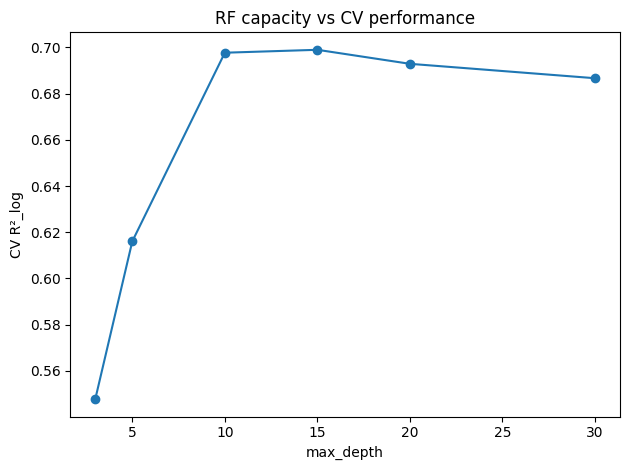

In [ ]:
# === 12. RF max_depth vs CV R²_log ===
import matplotlib.pyplot as plt
depths = [3,5,10,15,20,30]; scores=[]
for d in depths:
    s=[]
    for tr,val in gkf.split(X_train,y_train,groups=groups_train):
        m=RandomForestRegressor(n_estimators=60,max_depth=d,n_jobs=-1,random_state=42)
        m.fit(X_train[tr],y_train[tr])
        s.append(r2_score(y_train[val], np.clip(m.predict(X_train[val]),0,LOG_CLIP_MAX)))
    scores.append(np.mean(s)); print(f"depth={d}: {np.mean(s):.4f}")
plt.plot(depths,scores,'o-'); plt.xlabel('max_depth'); plt.yㅁlabel('CV R²_log')
plt.title('RF capacity vs CV performance'); plt.tight_layout()
plt.savefig('figures/bias_variance.png',dpi=120); plt.show()

In [ ]:
# === 13. 최종 test 평가 ===
from sklearn.ensemble import HistGradientBoostingRegressor

best_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42,
                                   **rf_search.best_params_)
best_model.fit(X_train, y_train)

final = []
final.append(evaluate(y_test, np.log1p(df_test['DL_bitrate'].values), "Persistence"))
final.append(evaluate(y_test, best_model.predict(X_test), "Random Forest (tuned)"))

gb_best = HistGradientBoostingRegressor(
    random_state=42, max_iter=200, learning_rate=0.1, max_depth=6
).fit(X_train, y_train)
final.append(evaluate(y_test, gb_best.predict(X_test), "Gradient Boosting (tuned)"))
pd.DataFrame(final).to_csv('artifacts/final_results.csv', index=False)

# 멀티시드 robustness
seeds=[42,0,7]; r=[]
for s in seeds:
    mm=RandomForestRegressor(n_estimators=100,n_jobs=-1,random_state=s,**rf_search.best_params_).fit(X_train,y_train)
    r.append(r2_score(y_test, np.clip(mm.predict(X_test),0,LOG_CLIP_MAX)))
print(f"\nseed robustness R²_log: {np.mean(r):.4f} ± {np.std(r):.4f}")
print("\n※ kbps에선 baseline이 이겨도 log에선 ML 압승 → heavy-tail 때문에 절대지표가 극단값에 지배됨(보고서 핵심)")

=== Persistence ===
  [주력] R²_log 0.1584 | RMSE_log 4.1192
  [보조] R²_kbps 0.7879 | RMSE_kbps 20,397 | MAE_kbps 6,839
=== Random Forest (tuned) ===
  [주력] R²_log 0.7607 | RMSE_log 2.1968
  [보조] R²_kbps 0.7418 | RMSE_kbps 22,505 | MAE_kbps 7,073
=== Gradient Boosting (tuned) ===
  [주력] R²_log 0.7521 | RMSE_log 2.2359
  [보조] R²_kbps 0.6796 | RMSE_kbps 25,073 | MAE_kbps 7,958

seed robustness R²_log: 0.7612 ± 0.0007

※ kbps에선 baseline이 이겨도 log에선 ML 압승 → heavy-tail 때문에 절대지표가 극단값에 지배됨(보고서 핵심)


In [ ]:
# === 14. Subgroup ===
df_test = df_test.copy()
df_test['y_pred_log'] = best_model.predict(X_test)
df_test['resid'] = df_test['y_log'] - np.clip(df_test['y_pred_log'], 0, LOG_CLIP_MAX)
for pfx,new in [('net_','NetworkCategory'),('app_','Application'),('mob_','Mobility')]:
    cols=[c for c in df_test.columns if c.startswith(pfx)]
    df_test[new]=df_test[cols].idxmax(axis=1).str[len(pfx):]

def subgroup(by):
    rows=[{by:g,'n':len(s),'r2_log':r2_score(s.y_log,s.y_pred_log),
           'rmse_log':np.sqrt(mean_squared_error(s.y_log,s.y_pred_log))}
          for g,s in df_test.groupby(by)]
    return pd.DataFrame(rows).sort_values('r2_log')

for by in ['NetworkCategory','Mobility','Application']:
    print(f"\n[{by}]"); print(subgroup(by).to_string(index=False))
print("\n[handover]")
print(subgroup('cellid_changed').to_string(index=False))  # 1=셀 변경 직후


[NetworkCategory]
NetworkCategory     n   r2_log  rmse_log
      3GorBelow  5302 0.351222  2.783102
            LTE  7021 0.773951  1.984448
             5G 31420 0.794214  2.128695

[Mobility]
Mobility     n   r2_log  rmse_log
 Driving 18979 0.728218  2.118337
  Static 24764 0.764968  2.255002

[Application]
 Application     n   r2_log  rmse_log
     Netflix 15350 0.410672  1.693911
Amazon_Prime 18257 0.516195  2.671846
    Download 10136 0.621288  1.903205

[handover]
 cellid_changed     n   r2_log  rmse_log
              1   390 0.708600  2.266546
              0 43353 0.760984  2.196113


In [ ]:
# === 15. Failure cases ===
thr = df_test['resid'].abs().quantile(0.99)
fail = df_test[df_test['resid'].abs() >= thr]
print(f"실패 row {len(fail)}개 (|residual| 상위 1%)\n")
print("NetworkCategory  실패 vs 전체:")
print(pd.concat([fail.NetworkCategory.value_counts(normalize=True),
                 df_test.NetworkCategory.value_counts(normalize=True)], axis=1,
                keys=['fail','all']).round(3))
print(f"\nhandover 비율  fail={fail.cellid_changed.mean():.3f}  all={df_test.cellid_changed.mean():.3f}")
print(f"Speed 평균     fail={fail.Speed.mean():.1f}  all={df_test.Speed.mean():.1f}")
fail.to_csv('artifacts/top_residuals.csv', index=False)

실패 row 438개 (|residual| 상위 1%)

NetworkCategory  실패 vs 전체:
                  fail    all
NetworkCategory              
5G               0.865  0.718
LTE              0.135  0.161
3GorBelow          NaN  0.121

handover 비율  fail=0.014  all=0.009
Speed 평균     fail=13.0  all=14.9


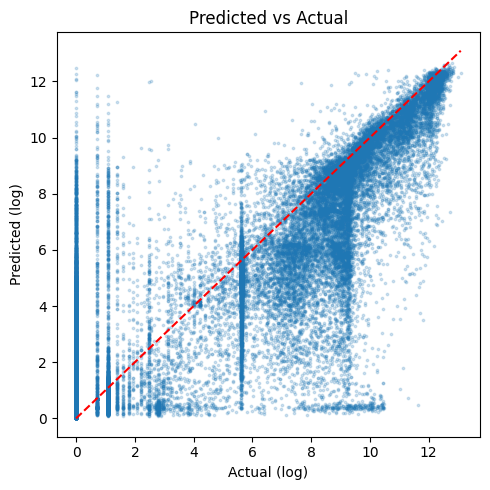

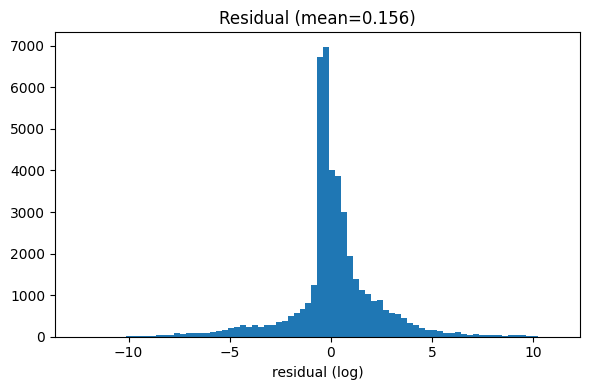

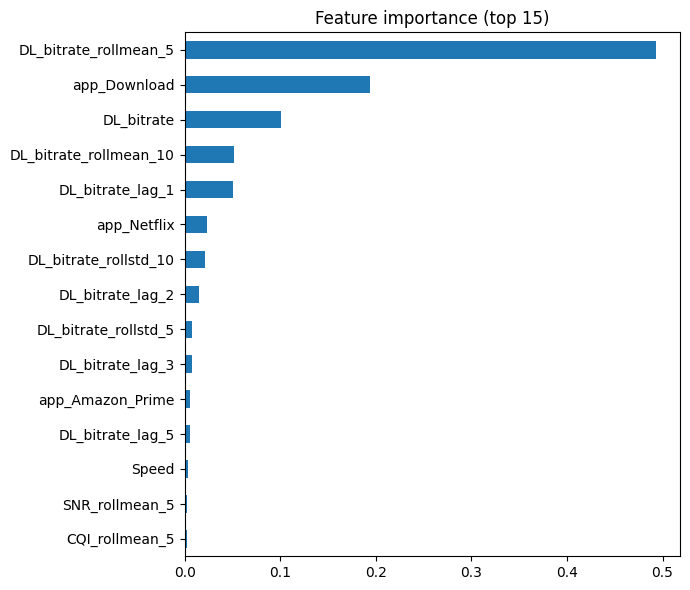

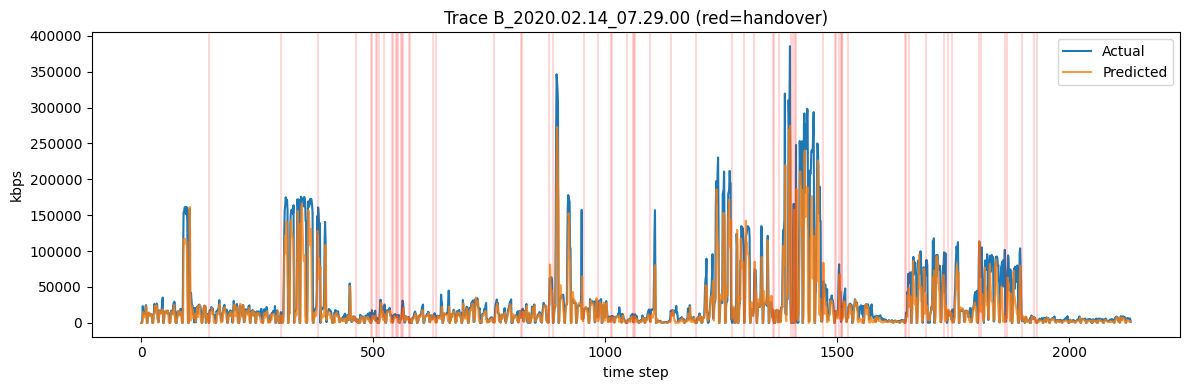

In [ ]:
# === 16. 시각화 ===
yp = np.clip(df_test['y_pred_log'].values, 0, LOG_CLIP_MAX)

# (1) Predicted vs Actual
plt.figure(figsize=(5,5)); plt.scatter(df_test.y_log, yp, s=3, alpha=0.2)
lim=[df_test.y_log.min(), df_test.y_log.max()]; plt.plot(lim,lim,'r--')
plt.xlabel('Actual (log)'); plt.ylabel('Predicted (log)'); plt.title('Predicted vs Actual')
plt.tight_layout(); plt.savefig('figures/pred_vs_actual.png',dpi=120); plt.show()

# (2) Residual histogram
plt.figure(figsize=(6,4)); plt.hist(df_test.resid, bins=80)
plt.title(f'Residual (mean={df_test.resid.mean():.3f})'); plt.xlabel('residual (log)')
plt.tight_layout(); plt.savefig('figures/residual_hist.png',dpi=120); plt.show()

# (3) Feature importance top 15
imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()[-15:]
imp.plot.barh(figsize=(7,6)); plt.title('Feature importance (top 15)')
plt.tight_layout(); plt.savefig('figures/feat_importance.png',dpi=120); plt.show()

# (4) 대표 trace 시간축 (보고서 메인 그림)
cand = df_test.groupby('trace_id').agg(n=('y_log','size'), ho=('cellid_changed','sum'))
tid = cand[cand.n>=60].sort_values('ho',ascending=False).index[0]
sub = df_test[df_test.trace_id==tid].sort_values('Timestamp')
plt.figure(figsize=(12,4))
plt.plot(np.expm1(sub.y_log.values), label='Actual', lw=1.5)
plt.plot(np.expm1(np.clip(sub.y_pred_log.values,0,LOG_CLIP_MAX)), label='Predicted', lw=1.5, alpha=.8)
for x in np.where(sub.cellid_changed.values==1)[0]: plt.axvline(x, color='red', alpha=.15)
plt.title(f'Trace {tid} (red=handover)'); plt.xlabel('time step'); plt.ylabel('kbps'); plt.legend()
plt.tight_layout(); plt.savefig('figures/trace_timeseries.png',dpi=120); plt.show()

In [ ]:
# === 17. Feature group ablation (자기완결 버전) ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np

best_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42,
                                   max_depth=15, min_samples_leaf=20)  # 알려진 best params
best_model.fit(X_train, y_train)

fgroups = {
 'Throughput History': [c for c in feature_cols if 'DL_bitrate' in c],
 'Radio KPI': ['RSRP','RSRQ','SNR','CQI','RSSI','RSRP_rollmean_5','SNR_rollmean_5','CQI_rollmean_5',
               'RSRQ_was_missing','SNR_was_missing','CQI_was_missing','RSSI_was_missing'],
 'Network Gen': ['net_3GorBelow','net_5G','net_LTE'],
 'Application': ['app_Amazon_Prime','app_Download','app_Netflix'],
 'Mobility':    ['mob_Driving','mob_Static','Speed'],
 'Cell Context':['cellid_changed'],
}
base = r2_score(y_test, np.clip(best_model.predict(X_test),0,LOG_CLIP_MAX))
print(f"Full model R²_log: {base:.4f}\n")
for g, cols in fgroups.items():
    keep = [i for i,c in enumerate(feature_cols) if c not in cols]
    m = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42,
                              max_depth=15, min_samples_leaf=20)
    m.fit(X_train[:,keep], y_train)
    s = r2_score(y_test, np.clip(m.predict(X_test[:,keep]),0,LOG_CLIP_MAX))
    print(f"  -{g:18s} 제거 → R²_log {s:.4f}  (Δ {s-base:+.4f})")

Full model R²_log: 0.7607

  -Throughput History 제거 → R²_log 0.4961  (Δ -0.2646)
  -Radio KPI          제거 → R²_log 0.7637  (Δ +0.0031)
  -Network Gen        제거 → R²_log 0.7605  (Δ -0.0001)
  -Application        제거 → R²_log 0.7471  (Δ -0.0136)
  -Mobility           제거 → R²_log 0.7646  (Δ +0.0039)
  -Cell Context       제거 → R²_log 0.7607  (Δ +0.0000)


In [1]:
!pip freeze > requirements.txt